# **🏠 House Price Prediction using Machine Learning**
## **📌 Problem Statement**

The real estate market is influenced by many factors such as the size of the house, location, construction quality, number of rooms, age of the property, and available amenities. Accurately predicting house prices helps buyers make informed purchasing decisions, assists sellers in setting competitive prices, and enables real estate companies to estimate property values more effectively.

The objective of this project is to develop a Machine Learning regression model that predicts the selling price of a house based on its features. Before building the model, the dataset will undergo comprehensive preprocessing, including handling missing values, detecting and treating outliers, feature engineering, feature scaling, function transformations where appropriate. Different preprocessing techniques will be evaluated to understand their impact on model performance and to build a robust and reliable prediction model.

## **🎯 Objective**

The main objectives of this project are to:

Analyze and understand the housing dataset.\
Perform Exploratory Data Analysis (EDA) to identify patterns and relationships.\
Handle missing values using appropriate imputation techniques.\
Detect and treat outliers.\
Create new features through feature engineering.\
Apply feature scaling and function transformations where necessary.\
Train and evaluate machine learning regression models.\
Compare model performance before and after preprocessing.

#### Importing Libraries:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Loading Dataset:

In [2]:
df= pd.read_csv('data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


#### Data Overview:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [4]:
df.shape

(4600, 18)

We have 4600 rows and 18 columns in dataset.

In [5]:
df.dtypes

date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street            object
city              object
statezip          object
country           object
dtype: object

We have to change the data type of date column as it is currently present in "Object" instead of "datetime" data type.

In [6]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [7]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [8]:
df.duplicated().sum()

np.int64(0)

We have 0 duplicate values.

In [9]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

We have 0 missing value which means our dataset is clean from null values.

#### Dataset Descriptiion:

| Column Name       | Data Type            | Description                                                                                       | Example                |
| ----------------- | -------------------- | ------------------------------------------------------------------------------------------------- | ---------------------- |
| **date**          | Date                 | Date when the house was sold. Can be used to extract year, month, or day for feature engineering. | `2014-05-02`           |
| **price**         | Numerical            | Selling price of the house. This is the target variable that the model will predict.              | `313000`               |
| **bedrooms**      | Numerical            | Number of bedrooms in the house.                                                                  | `3`                    |
| **bathrooms**     | Numerical            | Number of bathrooms. Decimal values (e.g., 1.5) indicate half bathrooms.                          | `2.5`                  |
| **sqft_living**   | Numerical            | Total living area of the house (in square feet).                                                  | `1340`                 |
| **sqft_lot**      | Numerical            | Total land area (lot size) in square feet.                                                        | `7912`                 |
| **floors**        | Numerical            | Number of floors in the house.                                                                    | `1`, `1.5`, `2`        |
| **waterfront**    | Categorical (Binary) | Indicates whether the property has a waterfront view (0 = No, 1 = Yes).                           | `1`                    |
| **view**          | Ordinal              | Quality of the property's view (0 = No View, 4 = Excellent View).                                 | `3`                    |
| **condition**     | Ordinal              | Overall condition of the house (1 = Poor, 5 = Excellent).                                         | `4`                    |
| **sqft_above**    | Numerical            | Living area above ground level (excluding basement).                                              | `1340`                 |
| **sqft_basement** | Numerical            | Basement area in square feet. A value of `0` indicates no basement.                               | `1000`                 |
| **yr_built**      | Numerical            | Year the house was originally built.                                                              | `1955`                 |
| **yr_renovated**  | Numerical            | Year the house was renovated. A value of `0` means the house has never been renovated.            | `2005`                 |
| **street**        | Categorical (Text)   | Street address of the property. Usually not useful for modeling due to high uniqueness.           | `18810 Densmore Ave N` |
| **city**          | Categorical          | City where the property is located.                                                               | `Seattle`              |
| **statezip**      | Categorical          | State and ZIP code of the property.                                                               | `WA 98133`             |
| **country**       | Categorical          | Country where the property is located.                                                            | `USA`                  |


**Target Variable: price**\
The objective of this project is to predict the selling price of a house using its structural, geographical, and historical features.

#### Changing the datatype of Date column:

In [10]:
df['date']= pd.to_datetime(df['date'])
df['date'].dtype

dtype('<M8[ns]')

Upon further exploration of the dataset, we observed that the *street* and *statezip* columns contain a large number of unique values (high cardinality). These features provide little useful information for predicting house prices and may increase the complexity of the model without improving its performance. Therefore, we decided to remove these columns from the dataset.

In [11]:
df.drop(columns= ['street' ,'statezip'] , inplace= True)

In [12]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'country'],
      dtype='object')

In [13]:
df['country'].value_counts()

country
USA    4600
Name: count, dtype: int64

Since all the observations in the dataset belong to the USA, the country column contains only a single unique value and does not provide any useful information for prediction. Therefore, this column will be removed from the dataset.

In [14]:
df.drop('country' , axis= 1 , inplace=True)

#### Feature Engineering :

In [15]:
df['sales_year'] = pd.to_datetime(df['date']).dt.year

In [16]:
df['house_Age'] = df['sales_year'] - df['yr_built']

In [17]:
df['house_Age'].value_counts()

house_Age
8     111
9     104
7      93
10     92
36     90
     ... 
99      6
79      6
81      5
80      4
78      3
Name: count, Length: 115, dtype: int64

In [18]:
df['yr_renovated'].value_counts()

yr_renovated
0       2735
2000     170
2003     151
2009     109
2001     109
2005      95
2004      77
2014      72
2006      68
2013      61
1923      57
1994      57
1989      55
2011      54
2012      45
2008      45
1988      43
2002      41
1983      41
1999      41
1998      40
1993      39
1912      33
1992      32
1979      32
2010      30
1985      29
1997      28
1996      22
1982      22
1972      17
1990      16
1956      15
1963      12
1969      11
1984      10
1968       9
1970       9
1954       8
1945       7
2007       7
1974       6
1934       6
1958       5
1986       5
1971       5
1978       3
1955       2
1980       2
1995       2
1981       1
1953       1
1987       1
1966       1
1960       1
1948       1
1991       1
1913       1
1977       1
1975       1
Name: count, dtype: int64

In [19]:
df['is_renovated'] = df['yr_renovated'].apply (lambda x : 0 if x==0 else 1)

In [20]:
df['is_renovated'].value_counts()

is_renovated
0    2735
1    1865
Name: count, dtype: int64

On calculating how many renovated houses we have we observed that we have 2735 houses that hasn't been renovated since they build ad 1865 houses that has renovated.

In [21]:
df['yr_since_renovated']= np.where(
    df['yr_renovated']==0,
    0,
    df['sales_year'] - df['yr_renovated']
    )

In [22]:
df['yr_since_renovated'].value_counts().head(15)

yr_since_renovated
0     2807
14     170
11     151
13     109
5      109
9       95
10      77
8       68
1       61
91      57
20      57
25      55
3       54
2       45
6       45
Name: count, dtype: int64

In [23]:
df.drop('yr_renovated' , axis = 1 , inplace=True)

The yr_renovated column is dropped because the useful information has already been extracted into the engineered features is_renovated and yr_since_renovated. Therefore, retaining the original column would be redundant.

#### Finding Outliers:

1. For Bedrooms and Bathrooms:

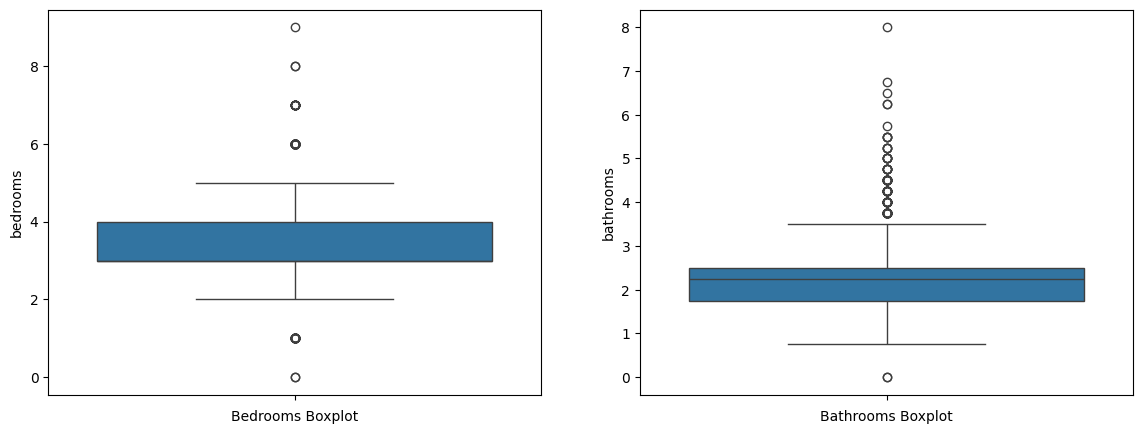

In [24]:
plt.figure(figsize=(14 , 5))

plt.subplot(121)
sns.boxplot(df['bedrooms'])
plt.xlabel('Bedrooms Boxplot')

plt.subplot(122)
sns.boxplot(df['bathrooms'])
plt.xlabel('Bathrooms Boxplot')
plt.show()

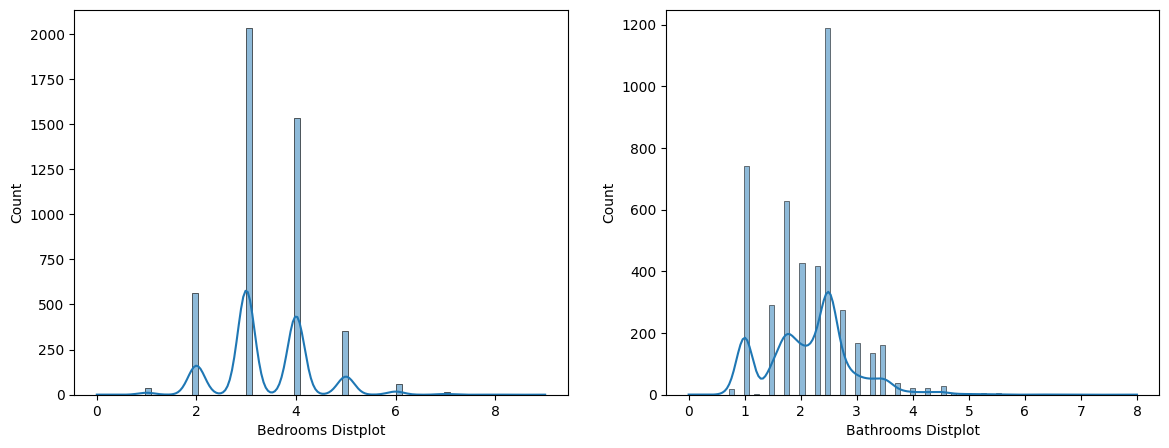

In [25]:
plt.figure(figsize=(14 , 5))

plt.subplot(121)
sns.histplot(df['bedrooms'] , kde = True)
plt.xlabel('Bedrooms Distplot')


plt.subplot(122)
sns.histplot(df['bathrooms'] , kde= True)
plt.xlabel('Bathrooms Distplot')
plt.show()

In [26]:
df.groupby(['bedrooms', 'floors']).size()

bedrooms  floors
0.0       2.0          1
          3.5          1
1.0       1.0         33
          1.5          1
          2.0          3
          3.0          1
2.0       1.0        389
          1.5         47
          2.0        112
          3.0         18
3.0       1.0       1078
          1.5        188
          2.0        661
          2.5         12
          3.0         92
          3.5          1
4.0       1.0        508
          1.5        158
          2.0        841
          2.5         14
          3.0         10
5.0       1.0        135
          1.5         43
          2.0        164
          2.5          8
          3.0          3
6.0       1.0         25
          1.5          6
          2.0         22
          2.5          5
          3.0          3
7.0       1.0          5
          1.5          1
          2.0          6
          2.5          1
          3.0          1
8.0       1.0          1
          2.0          1
9.0       2.5          1
dtype: i

In [27]:
df['bedrooms'].value_counts().sort_index()

bedrooms
0.0       2
1.0      38
2.0     566
3.0    2032
4.0    1531
5.0     353
6.0      61
7.0      14
8.0       2
9.0       1
Name: count, dtype: int64

In [28]:
df[df['bedrooms']== 0]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,city,sales_year,house_Age,is_renovated,yr_since_renovated
2365,2014-06-12,1095000.0,0.0,0.0,3064,4764,3.5,0,2,3,3064,0,1990,Seattle,2014,24,1,5
3209,2014-06-24,1295648.0,0.0,0.0,4810,28008,2.0,0,0,3,4810,0,1990,Redmond,2014,24,1,5


In [29]:
df.drop(df[df['bedrooms']== 0].index , inplace = True)

The bedrooms feature contained two observations with 0 bedrooms. After further investigation, these records were found to also have 0 bathrooms despite having large living areas and high selling prices, indicating potential data quality issues. Therefore, these two observations were removed from the dataset. The remaining bedroom counts, including houses with 6–9 bedrooms, were retained as they likely represent valid large residential properties rather than outliers.

#### Using IQR method on bathroom column:

In [30]:
Q1 = df['bathrooms'].quantile(0.25)
Q3 = df['bathrooms'].quantile(0.75)
IQR = Q3 - Q1
print('Q1:',Q1)
print('Q3',Q3)
print('IQR',IQR)

Q1: 1.75
Q3 2.5
IQR 0.75


In [31]:
upper_limit_bath = Q3 + 1.5 * IQR
lower_limit_bath = Q1 - 1.5 * IQR

print(upper_limit_bath)
print(lower_limit_bath)

3.625
0.625


#### Using z-score method on bathroom column:

In [32]:
upper_limit = df['bathrooms'].mean() + 3 * df['bathrooms'].std()
lower_limit = df['bathrooms'].mean() - 3 * df['bathrooms'].std()
print('Upper limit:',upper_limit)
print('Lower limit:',lower_limit)

Upper limit: 4.509718058569327
Lower limit: -0.1862078367337463


In [33]:
df['bathrooms'].value_counts().sort_index()

bathrooms
0.75      17
1.00     743
1.25       3
1.50     291
1.75     629
2.00     427
2.25     419
2.50    1189
2.75     276
3.00     167
3.25     136
3.50     162
3.75      37
4.00      23
4.25      23
4.50      29
4.75       7
5.00       6
5.25       4
5.50       4
5.75       1
6.25       2
6.50       1
6.75       1
8.00       1
Name: count, dtype: int64

In [34]:
df.drop(df[df['bathrooms']== 0].index , inplace = True)

The bathrooms feature contained two observations with a value of 0. As houses without bathrooms are highly unrealistic in the context of this residential housing dataset, these records were considered invalid and removed. The remaining high bathroom counts (e.g., 5–8 bathrooms) were retained, as they may correspond to genuine luxury properties rather than erroneous data.

2. for Sqft Living and Sqft Lot:

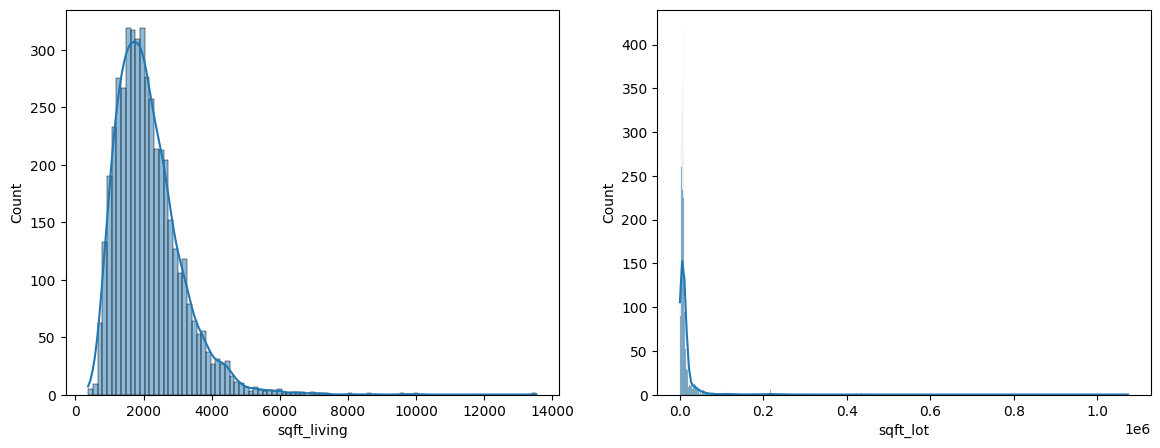

In [35]:
plt.figure(figsize=(14 , 5))

plt.subplot(121)
sns.histplot(df['sqft_living'] , kde= True) 

plt.subplot(122)
sns.histplot(df['sqft_lot'] , kde= True)
plt.show()

In [36]:
df['sqft_lot'].value_counts()

sqft_lot
5000     80
6000     65
4000     54
7200     50
4800     29
         ..
14892     1
6435      1
1075      1
18226     1
8892      1
Name: count, Length: 3111, dtype: int64

In [37]:
(df['sqft_lot'] == 0).value_counts()

sqft_lot
False    4598
Name: count, dtype: int64

In [38]:
df['sqft_living'].value_counts()

sqft_living
1940    32
1720    32
1660    31
1840    31
2000    30
        ..
490      1
3831     1
1954     1
8020     1
3206     1
Name: count, Length: 564, dtype: int64

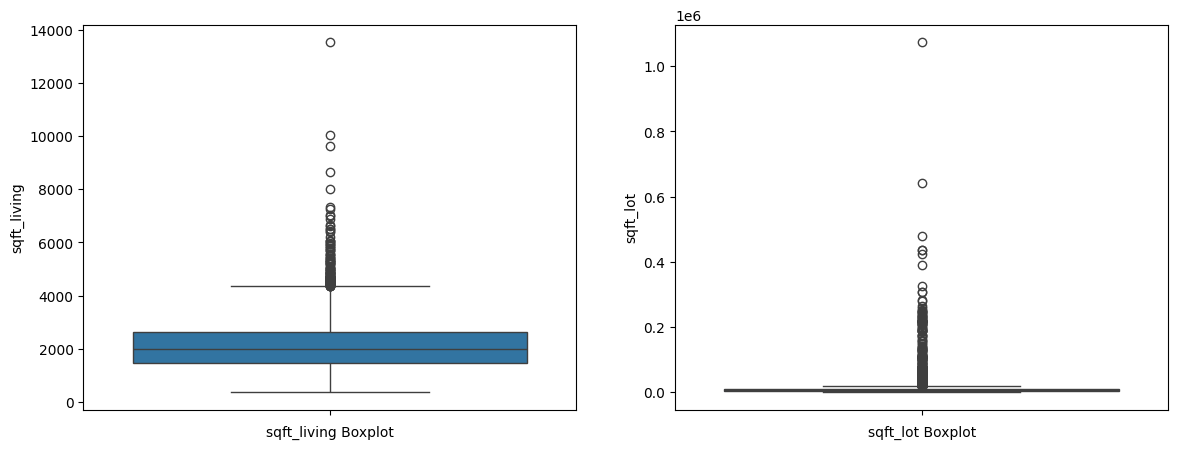

In [39]:
plt.figure(figsize=(14 , 5))

plt.subplot(121)
sns.boxplot(df['sqft_living'])
plt.xlabel('sqft_living Boxplot')

plt.subplot(122)
sns.boxplot(df['sqft_lot'])
plt.xlabel('sqft_lot Boxplot')
plt.show()

In [40]:
Q1 = df['sqft_living'].quantile(0.25)
Q3 = df['sqft_living'].quantile(0.75)
IQR = Q3 - Q1
print('Q1:',Q1)
print('Q3',Q3)
print('IQR',IQR)

Q1: 1460.0
Q3 2620.0
IQR 1160.0


In [41]:
upper_limit_sqft_liv = Q3 + 1.5 * IQR
lower_limit_sqft_liv = Q1 - 1.5 * IQR

print(upper_limit_sqft_liv)
print(lower_limit_sqft_liv)

4360.0
-280.0


In [42]:
Q1 = df['sqft_lot'].quantile(0.25)
Q3 = df['sqft_lot'].quantile(0.75)
IQR = Q3 - Q1
print('Q1:',Q1)
print('Q3',Q3)
print('IQR',IQR)

Q1: 5001.0
Q3 11000.0
IQR 5999.0


In [43]:
upper_limit_sqft_lot = Q3 + 1.5 * IQR
lower_limit_sqft_lot = Q1 - 1.5 * IQR

print(upper_limit_sqft_lot)
print(lower_limit_sqft_lot)

19998.5
-3997.5


In [44]:
df['sqft_lot'].describe()

count    4.598000e+03
mean     1.485185e+04
std      3.589141e+04
min      6.380000e+02
25%      5.001000e+03
50%      7.683000e+03
75%      1.100000e+04
max      1.074218e+06
Name: sqft_lot, dtype: float64

The sqft_living and sqft_lot features contain several extreme values identified by the boxplot and IQR method. However, these values likely represent genuine large residential properties and luxury estates rather than data entry errors. Therefore, these observations were retained to preserve valuable information. If required, a suitable transformation (e.g., logarithmic transformation) can be applied later to reduce skewness while maintaining the integrity of the data.

In [45]:
(df['house_Age'] < 0).sum()

np.int64(0)

In [46]:
(df['yr_since_renovated'] < 0 ).sum()

np.int64(0)

hence , there are no negative values in house_Age and yr_since_renovated column. 

3. price

<Axes: ylabel='price'>

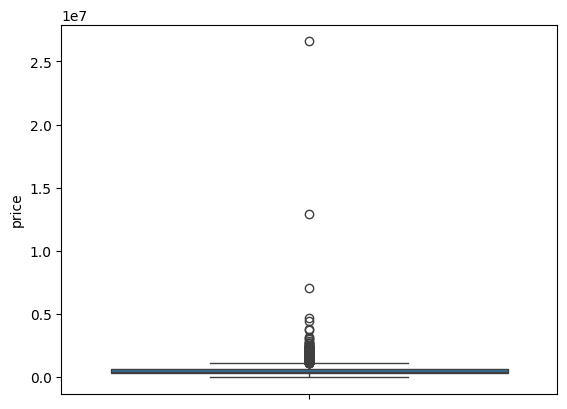

In [47]:
sns.boxplot(df['price'])

<Axes: xlabel='price', ylabel='Count'>

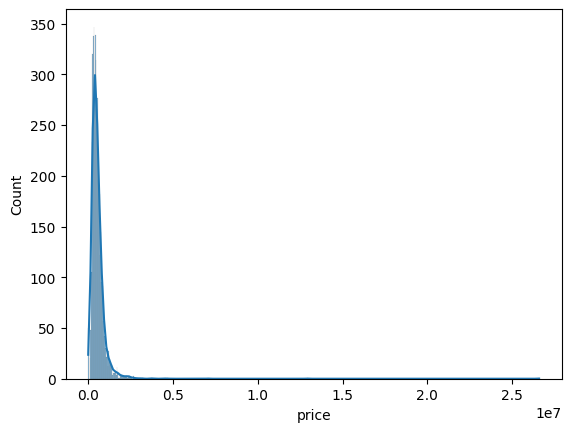

In [48]:
sns.histplot(df['price'] , kde= True)

In [49]:
Q3= df['price'].quantile(0.75)
Q1 = df['price'].quantile(0.25)
IQR = Q3 - Q1
print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:',IQR)

Q1: 322625.0
Q3: 653750.0
IQR: 331125.0


In [50]:
lower_limit_price = Q1 - 1.5 * IQR
upper_limit_price = Q3 + 1.5 * IQR

print(upper_limit_price)
print(lower_limit_price)

1150437.5
-174062.5


In [51]:
(df['price']==0).value_counts()

price
False    4549
True       49
Name: count, dtype: int64

In [52]:
df.drop(df[df['price'] == 0].index , inplace = True)

In [53]:
(df['price']==0).value_counts()

price
False    4549
Name: count, dtype: int64

In [54]:
df = df[df['price'] <= upper_limit_price]

In [55]:
df['price'].describe()

count    4.310000e+03
mean     4.873159e+05
std      2.154859e+05
min      7.800000e+03
25%      3.200000e+05
50%      4.500000e+05
75%      6.150000e+05
max      1.150000e+06
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

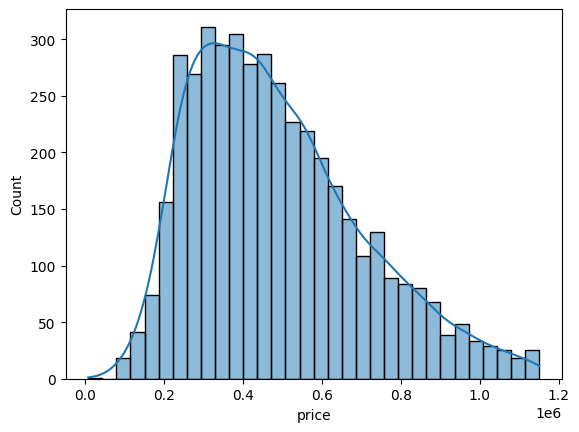

In [56]:
sns.histplot(df['price'] , kde= True)

The price column contained two types of outliers: 49 listings priced at $0 (likely gifts, transfers, or non-market transactions rather than real sales) and a small number of extreme high-value listings above the IQR upper bound of $1,150,437.5. Both were removed — the $0 entries as invalid data, and the extreme high-end values because they disproportionately inflated price variance and severely distorted model performance during initial testing.

## **Insights of the Data:**

##### Q1. Which city has the highest number of house sales?

In [57]:
df['city'].unique()

array(['Shoreline', 'Kent', 'Bellevue', 'Redmond', 'Seattle',
       'Maple Valley', 'North Bend', 'Lake Forest Park', 'Sammamish',
       'Auburn', 'Des Moines', 'Bothell', 'Federal Way', 'Kirkland',
       'Issaquah', 'Woodinville', 'Normandy Park', 'Fall City', 'Renton',
       'Carnation', 'Snoqualmie', 'Duvall', 'Burien', 'Covington',
       'Inglewood-Finn Hill', 'Kenmore', 'Newcastle', 'Black Diamond',
       'Ravensdale', 'Clyde Hill', 'Algona', 'Mercer Island', 'Skykomish',
       'Tukwila', 'Vashon', 'SeaTac', 'Enumclaw', 'Snoqualmie Pass',
       'Pacific', 'Beaux Arts Village', 'Preston', 'Milton',
       'Yarrow Point', 'Medina'], dtype=object)

<Axes: xlabel='city'>

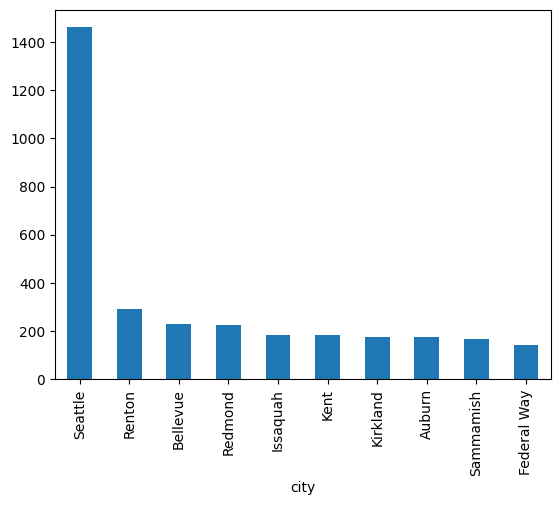

In [58]:
df['city'].value_counts().head(10).plot(kind= 'bar')

Seattle recorded the highest number of house sales with 1,460 properties sold, making it the most active housing market in the dataset. It is followed by Renton (291), Bellevue (232), and Redmond (227). This indicates that a significant portion of the house sales occurred in Seattle compared to other cities.

#### Q2. Which city has the highest average house price?

In [59]:
df.groupby('city')['price'].mean().sort_values(ascending=False)

city
Clyde Hill             994000.000000
Mercer Island          811107.186667
Beaux Arts Village     745000.000000
Bellevue               681543.557830
Sammamish              674910.103121
Redmond                640074.857593
Newcastle              631598.096774
Woodinville            593763.761261
Kirkland               585231.145948
Issaquah               577834.605343
Preston                562450.000000
Snoqualmie             551850.376812
Snoqualmie Pass        525000.000000
Ravensdale             514071.428571
Seattle                508949.622855
Fall City              496611.111111
Yarrow Point           491675.000000
Normandy Park          488298.437500
Bothell                481441.893939
Lake Forest Park       474855.882353
Vashon                 472556.896552
Kenmore                454378.564103
Carnation              452978.238095
Inglewood-Finn Hill    425000.000000
Duvall                 403994.126984
North Bend             399565.706667
Shoreline              396431.907

<Axes: xlabel='city'>

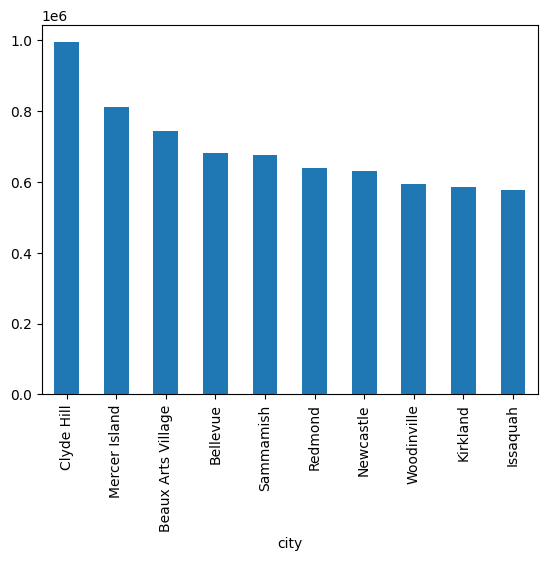

In [60]:
df.groupby('city')['price'].mean().sort_values(ascending=False).head(10).plot(kind= 'bar')

The average house prices vary considerably across different cities. Clyde Hill has the highest average house price at approximately $994,000, followed by Mercer Island and Beaux Arts Village. In contrast, Medina has the lowest average house price at approximately $188,000. This indicates that location is an important factor influencing house prices.

#### Q3. What is the average price of the houses?

In [61]:
df['price'].mean()

np.float64(487315.9406287993)

The average selling price of houses in the dataset is approximately $487,316.

#### Q4. What is the price distribution of houses?

Text(0.5, 1.0, 'Price Distribution')

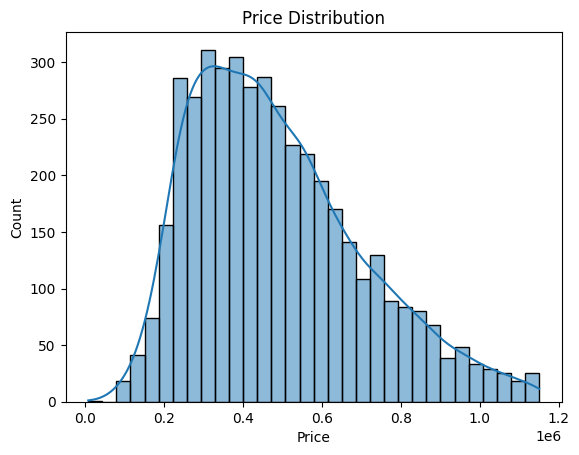

In [62]:
sns.histplot(df['price'] , kde= True)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution')

The price distribution graph shows that house prices are positively skewed (right-skewed). Most of the houses in the dataset have prices between approximately $200,000 and $600,000, with the highest concentration around $300,000 to $450,000. However, there are fewer houses with very high prices, extending up to around $1.1 million, creating the long tail on the right side.

#### Q5. What are the average sale price of the house with and without basement?

In [63]:
df.groupby(df['sqft_basement'] > 0)['price'].mean().rename(index={
    True: 'With Basement:',
    False: 'Without Basement:'
})

sqft_basement
Without Basement:    460826.301278
With Basement:       528865.839778
Name: price, dtype: float64

<Axes: xlabel='sqft_basement'>

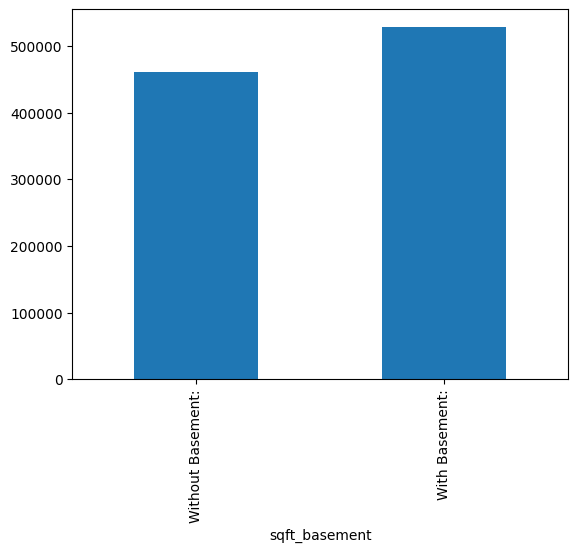

In [64]:
df.groupby(df['sqft_basement'] > 0)['price'].mean().rename(index={
    True: 'With Basement:',
    False: 'Without Basement:'
}).plot(kind = 'bar' )

Houses with a basement have a higher average selling price (approximately $528,866) compared to houses without a basement (approximately $460,826). This suggests that the presence of a basement may contribute to a higher house selling price.

#### Q6. Does a larger above-ground living area lead to a higher house price?

Text(0, 0.5, 'price')

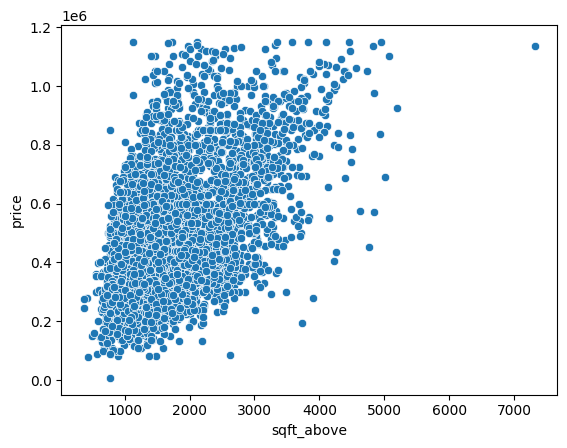

In [65]:
sns.scatterplot(df, x= 'sqft_above' , y= 'price')
plt.xlabel('sqft_above')
plt.ylabel('price')

The scatter plot shows a positive relationship between sqft_above and house price. Generally, as the above-ground living area of a house increases, its price also tends to increase. However, the data points are widely scattered, which indicates that sqft_above alone does not completely determine the price of a house. Other factors, such as location, number of bathrooms and bedrooms, waterfront status, view, and condition, also play an important role in determining house prices.

#### Q7. What are the average sale price of the houses based on number of floors?

In [66]:
df['floors'].value_counts()

floors
1.0    2106
2.0    1640
1.5     415
3.0     120
2.5      28
3.5       1
Name: count, dtype: int64

In [67]:
df.groupby('floors')['price'].mean()

floors
1.0    419606.323412
1.5    533296.329875
2.0    558646.994036
2.5    687621.392857
3.0    494373.674074
3.5    563500.000000
Name: price, dtype: float64

<Axes: xlabel='floors'>

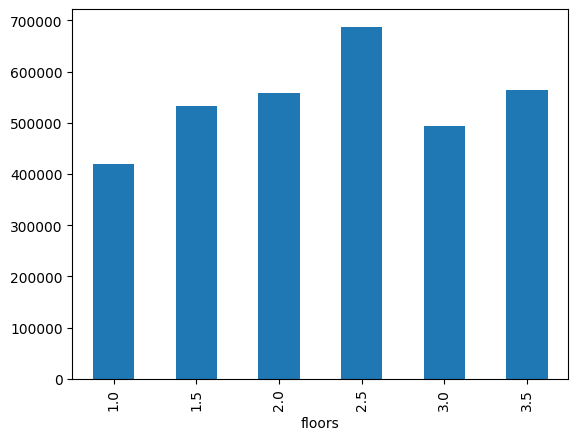

In [68]:
df.groupby('floors')['price'].mean().plot(kind='bar')

The average selling price varies according to the number of floors. Houses with 2.5 floors have the highest average selling price of approximately $687,621, while houses with 1 floor have the lowest average selling price of approximately $419,606.

#### Q8. What are the average sale price of the houses based on number of Bedrooms?

In [69]:
df['bedrooms'].value_counts()

bedrooms
3.0    1981
4.0    1394
2.0     557
5.0     282
6.0      47
1.0      37
7.0      10
9.0       1
8.0       1
Name: count, dtype: int64

In [70]:
df.groupby('bedrooms')['price'].mean()

bedrooms
1.0    281483.783784
2.0    387354.408877
3.0    447831.631270
4.0    563878.336313
5.0    586555.804965
6.0    608272.340426
7.0    602200.000000
8.0    340000.000000
9.0    599999.000000
Name: price, dtype: float64

<Axes: xlabel='bedrooms'>

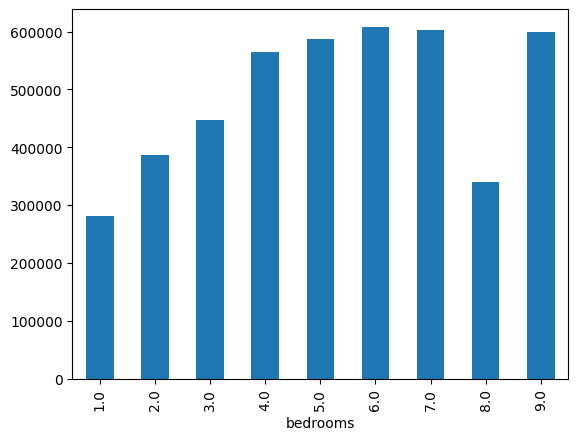

In [71]:
df.groupby('bedrooms')['price'].mean().plot(kind='bar')

The average selling price generally increases as the number of bedrooms increases, rising from approximately $281,484 for 1-bedroom houses to around $608,272 for 6-bedroom houses. However, the trend is not consistent for houses with 7 or more bedrooms, likely because there are fewer observations in these categories.

#### Q9. What are the average price based on view? 

In [72]:
df['view'].value_counts()

view
0    3978
2     169
3      75
1      56
4      32
Name: count, dtype: int64

In [73]:
df.groupby('view')['price'].mean()

view
0    473422.059426
1    663760.352041
2    613117.360947
3    687278.000000
4    772671.500000
Name: price, dtype: float64

<Axes: xlabel='view'>

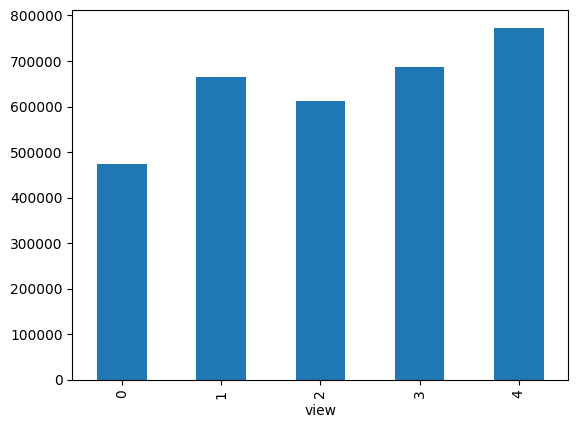

In [74]:
df.groupby('view')['price'].mean().plot(kind='bar')

The average selling price generally increases with better view ratings. Houses with a view rating of 4 have the highest average selling price of approximately $772,672, while houses with a view rating of 0 have the lowest average selling price of approximately $473,422. This suggests that properties with better views tend to have higher selling prices.

#### Q9. How many houses have been renovated? 

In [75]:
df['is_renovated'].value_counts()

is_renovated
0    2559
1    1751
Name: count, dtype: int64

<Axes: xlabel='is_renovated'>

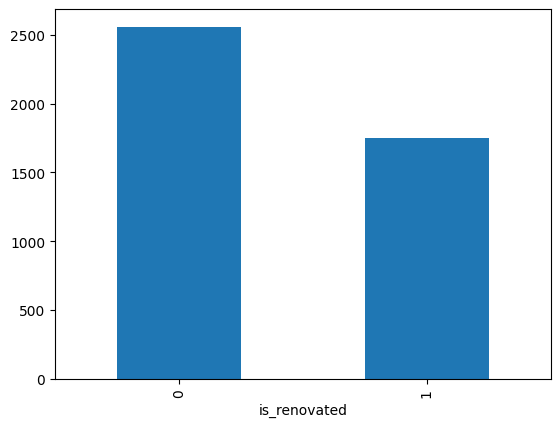

In [76]:
df['is_renovated'].value_counts().plot(kind='bar')

The dataset contains 2,559 non-renovated houses and 1,751 renovated houses. This indicates that non-renovated properties are more common than renovated ones in the dataset.

#### Q10. Do renovated houses have a higher average selling price than non-renovated houses?

In [77]:
df['is_renovated'].value_counts()

is_renovated
0    2559
1    1751
Name: count, dtype: int64

In [78]:
df.groupby('is_renovated')['price'].mean().rename(index={
    0: 'Not Renovated',
    1: 'Renovated'
})

is_renovated
Not Renovated    499986.952695
Renovated        468797.882447
Name: price, dtype: float64

The average selling price of non-renovated houses is approximately $499,987, while renovated houses have an average selling price of approximately $468,798. In this dataset, non-renovated houses have a higher average selling price than renovated houses.

#### Q11: How does the condition of a house affect its average selling price? 

In [79]:
df['condition'].value_counts()

condition
3    2704
4    1185
5     385
2      30
1       6
Name: count, dtype: int64

In [80]:
df.groupby('condition')['price'].mean()

condition
1    306633.333333
2    260832.000000
3    490775.119119
4    467136.768070
5    545594.680127
Name: price, dtype: float64

Houses with a condition rating of 5 have the highest average selling price of approximately $545,595, while houses with a condition rating of 2 have the lowest average selling price of approximately $260,832. Overall, houses in better condition tend to have higher average selling prices, although the relationship is not perfectly consistent across all condition ratings.

#### Q12. How does waterfront status affect the average selling price of houses?

In [81]:
df['waterfront'].value_counts()

waterfront
0    4294
1      16
Name: count, dtype: int64

In [82]:
df.groupby('waterfront')['price'].mean()

waterfront
0    486362.413626
1    743218.750000
Name: price, dtype: float64

<Axes: xlabel='waterfront'>

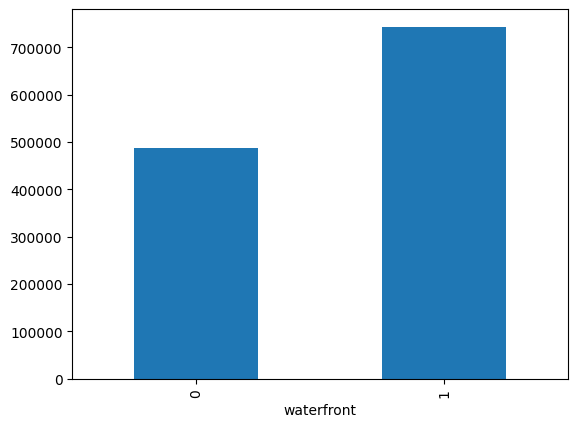

In [83]:
df.groupby('waterfront')['price'].mean().plot(kind= 'bar')

Waterfront properties have a higher average selling price of approximately $743,219 compared to non-waterfront properties, which have an average selling price of approximately $486,362. This suggests that waterfront properties tend to be more expensive than non-waterfront properties in the dataset.

#### Q13. Is there a relationship between the living area (sqft_living) and the selling price of houses?

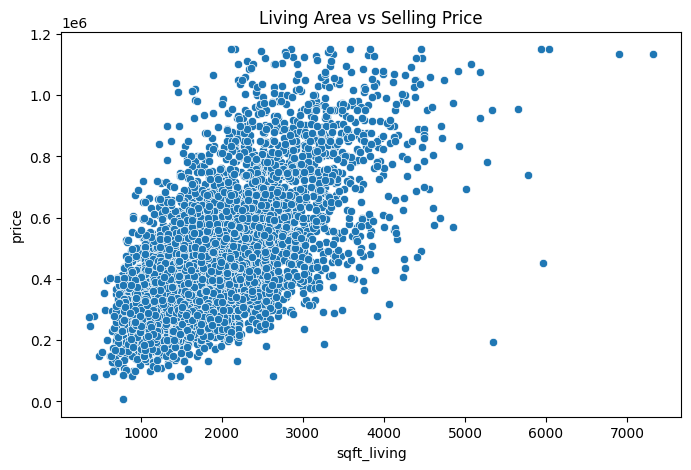

In [84]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='sqft_living', y='price', data=df)
plt.title('Living Area vs Selling Price')
plt.show()

In [85]:
df[['sqft_living' , 'price']].corr()

,sqft_living,price
sqft_living,1.00000,0.63164
price,0.63164,1.00000


The correlation between sqft_living and price is 0.43, indicating a moderate positive relationship. This means that, in general, houses with larger living areas tend to have higher selling prices. However, the correlation is not very strong, suggesting that other factors such as location, condition, waterfront access, and number of bedrooms also play an important role in determining house prices.

#### Q14. Is there a relationship between the lot size (sqft_lot) and the selling price of houses?

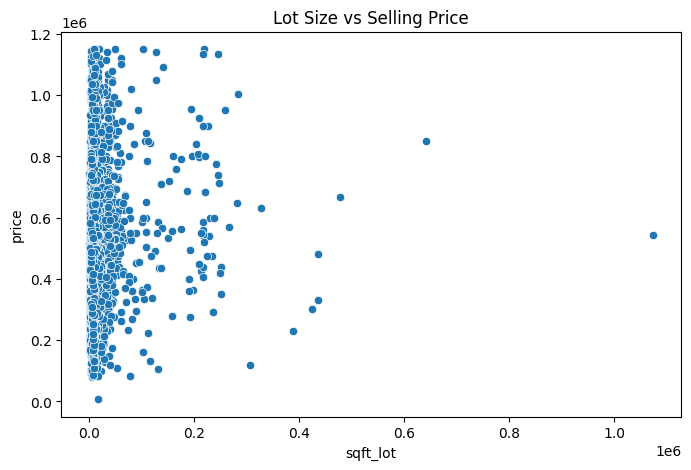

In [86]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='sqft_lot', y='price', data=df)
plt.title('Lot Size vs Selling Price')
plt.show()

This scatter plot shows that a property's lot size (sqft_lot) has almost no effect on its selling price (price). Most homes are clustered in smaller lot sizes under 100,000 square feet, yet their prices span across the entire scale from cheap to over $1.2 million. Even homes with massive, multi-acre lots don't fetch the highest prices.

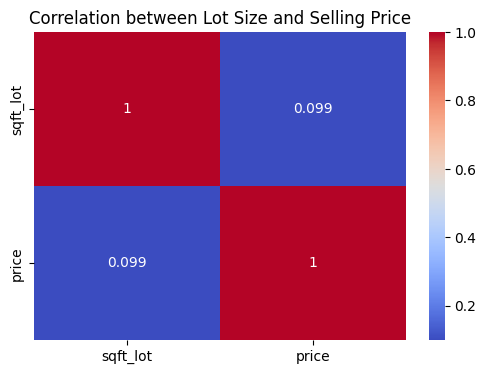

In [87]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    df[['sqft_lot', 'price']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation between Lot Size and Selling Price')
plt.show()

The correlation coefficient between sqft_lot and price is 0.05, indicating a very weak positive relationship. The scatter plot also shows no clear upward trend, suggesting that larger lot sizes do not necessarily result in higher selling prices. Therefore, lot size alone is not a strong predictor of house prices in this dataset.

In [88]:
df['floors'].value_counts()

floors
1.0    2106
2.0    1640
1.5     415
3.0     120
2.5      28
3.5       1
Name: count, dtype: int64

#### Q15. What is the relationship among the numerical features in the dataset?

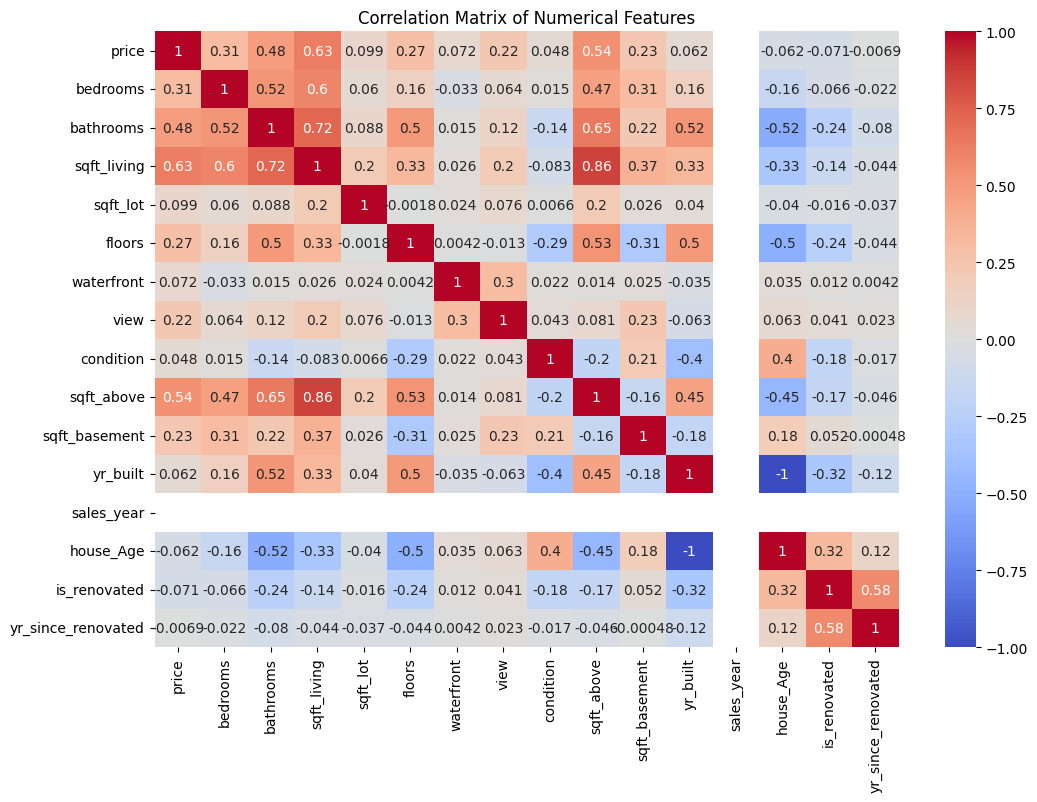

In [89]:
plt.figure(figsize = (12, 8))

sns.heatmap(
    df.corr(numeric_only= True), annot= True , cmap= 'coolwarm'
)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

The correlation matrix reveals that interior space is what truly drives home value. Selling price shows strong positive correlations with living area size (sqft_living at 0.63), above-ground space (sqft_above at 0.54), and bathroom count (bathrooms at 0.48). Essentially, buyers pay for indoor livable room rather than land size. The heatmap also highlights logical relationships between non-price variables. For example, house_Age and yr_built have a perfect inverse relationship (-1.0) since newer builds naturally mean lower age. Additionally, older homes tend to have fewer floors and bathrooms, while features like sqft_living and sqft_above overlap heavily (0.86 correlation).

## **Model Evaluation:**

In [90]:
df.columns 

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'city', 'sales_year', 'house_Age',
       'is_renovated', 'yr_since_renovated'],
      dtype='object')

In [91]:
df.drop(columns=['yr_built' , 'date' , 'sales_year'] , axis=1 , inplace= True)

The date column was removed because the relevant information, sales_year, had already been extracted from it. Since all houses in the dataset were sold in the same year (2014), the sales_year column provides no meaningful variation and was also removed. Additionally, the yr_built column was dropped because its information was already captured through the engineered house_Age feature. Keeping both yr_built and house_Age would provide nearly duplicate information to the model.

#### 1. Train Test Split:

In [93]:
from sklearn.model_selection import train_test_split
X = df[[
        'bedrooms',
        'bathrooms',
        'sqft_living',
        'sqft_lot',
        'floors',
        'waterfront',
        'view',
        'condition',
        'sqft_above',
        'sqft_basement',
        'house_Age',
        'is_renovated',
        'yr_since_renovated',
        'city'
    ]]

y = df['price']

In [94]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [95]:
X_train.shape , y_train.shape

((3448, 14), (3448,))

#### 2. Showing Distribution Graphs:

In [96]:
continuous_cols = [
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'sqft_above',
    'sqft_basement',
    'house_Age',
    'yr_since_renovated'
]

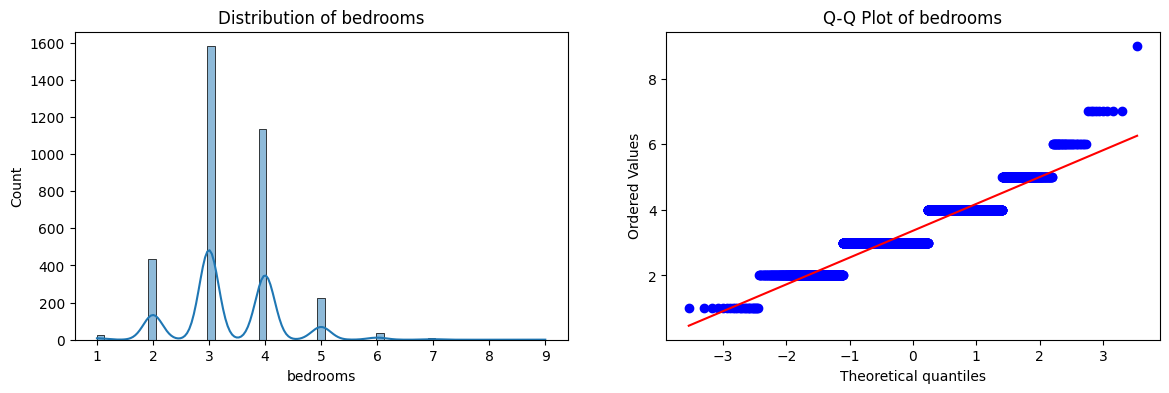

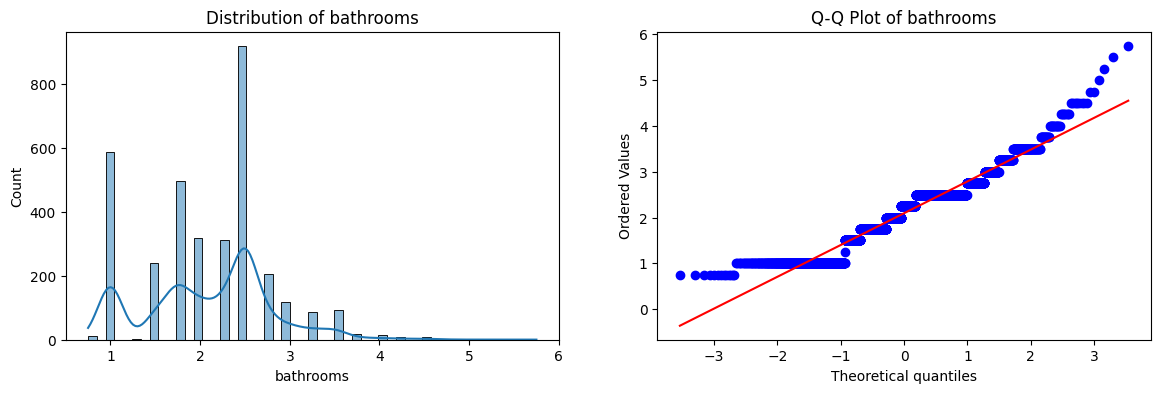

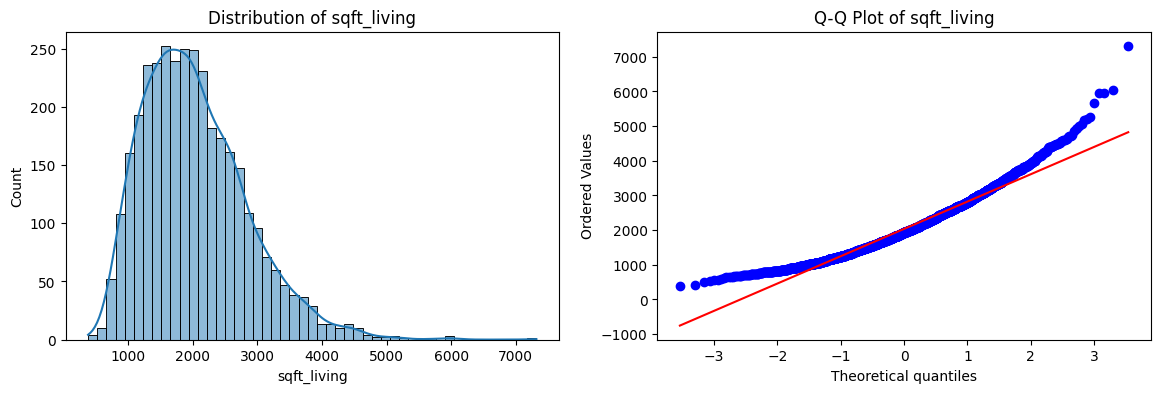

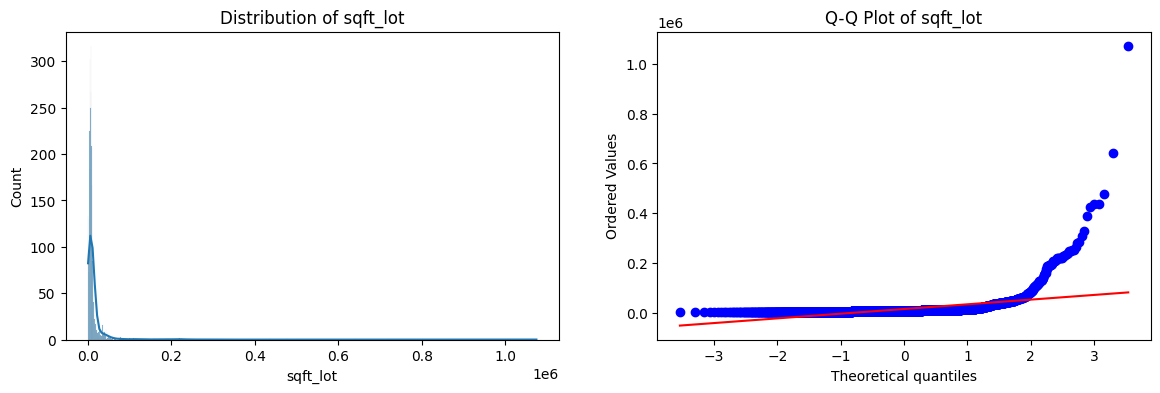

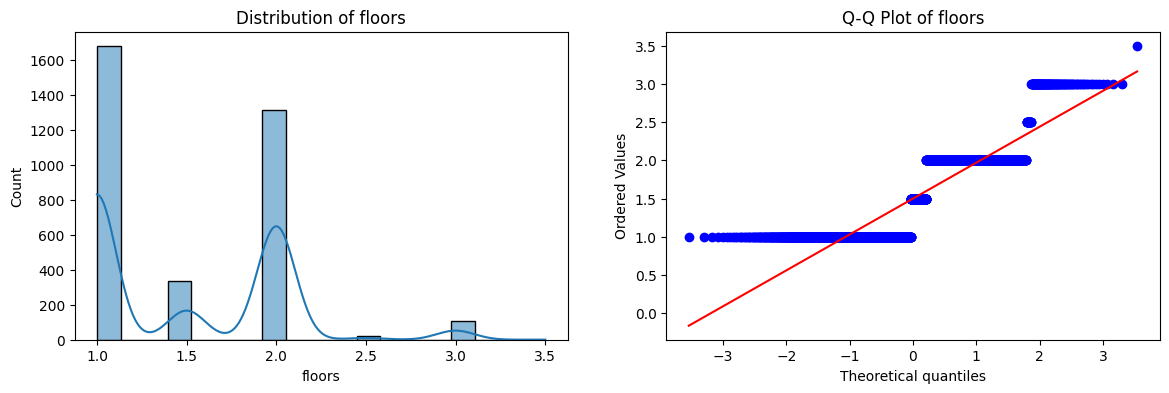

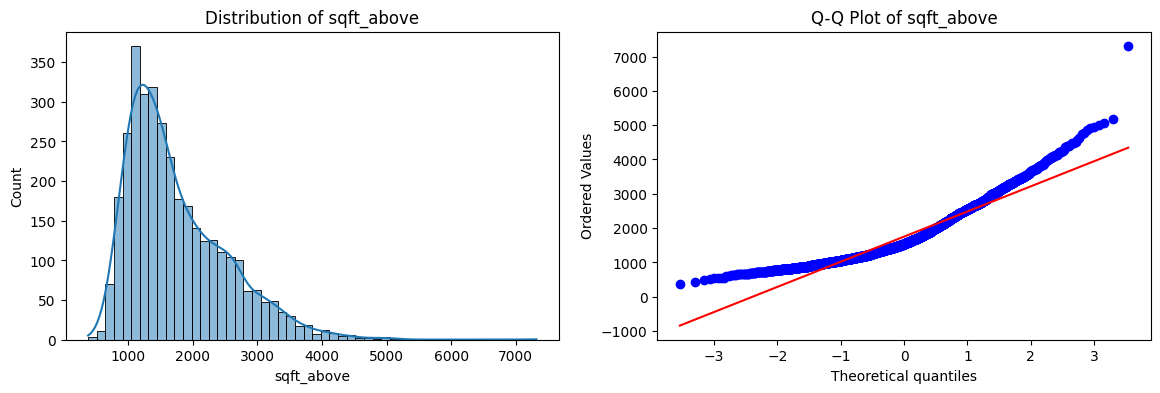

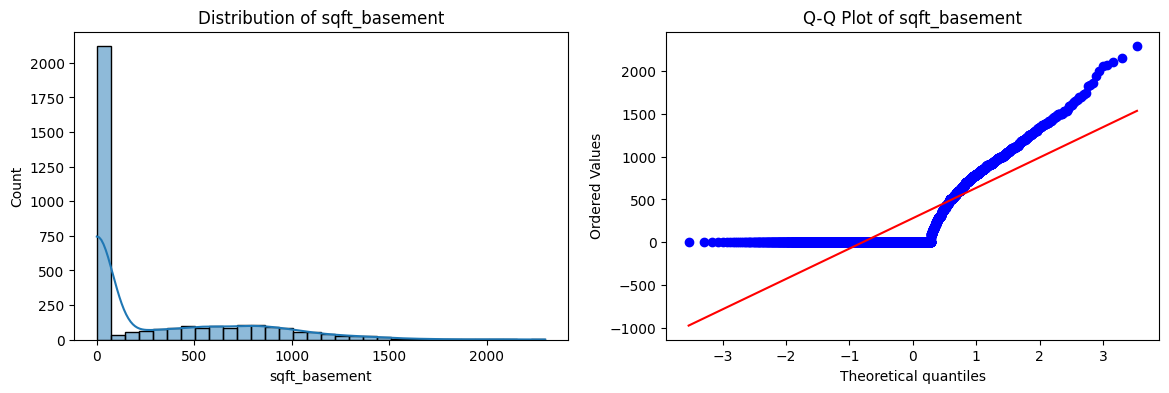

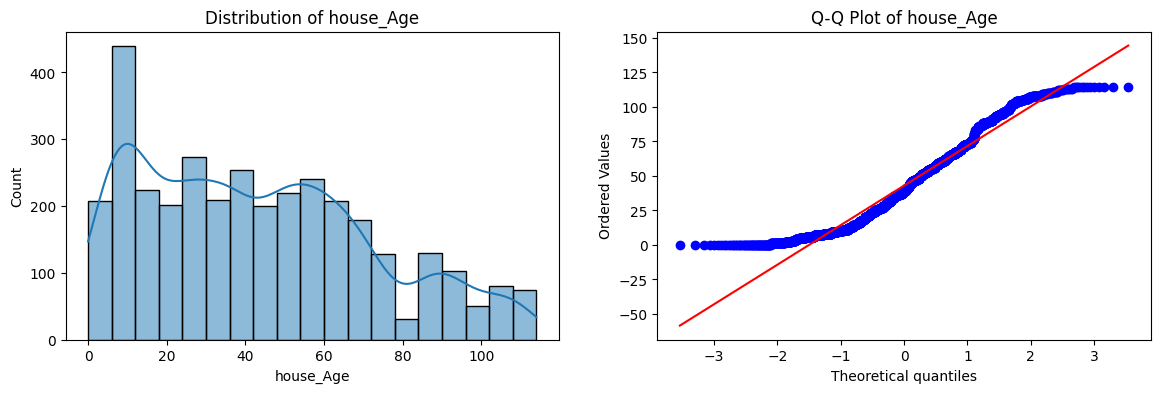

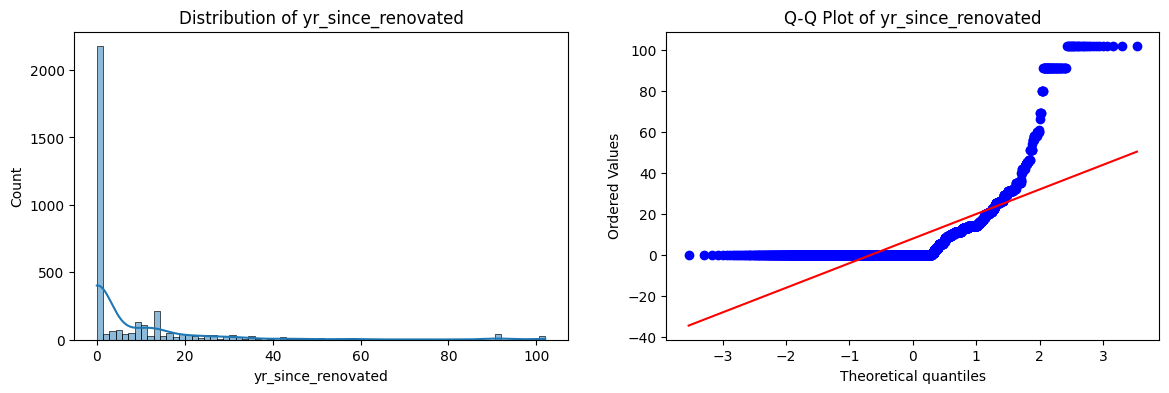

In [97]:
import scipy.stats as stats

for col in continuous_cols:
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(X_train[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.subplot(1, 2, 2)
    stats.probplot(X_train[col], dist='norm', plot=plt)
    plt.title(f'Q-Q Plot of {col}')

    plt.show()

The distribution of the numerical features was analyzed using histograms and Q-Q plots. The analysis showed that bathrooms, sqft_living, sqft_lot, and sqft_above were considerably right-skewed. Therefore, these continuous features were selected for Yeo-Johnson transformation to reduce skewness and improve their suitability for the Linear Regression model. Discrete features such as bedrooms and floors were retained without transformation due to their limited number of distinct values. Features containing a large number of zero values, such as sqft_basement and yr_since_renovated, were not blindly transformed and were handled separately.

#### 3. Before and After Comparison:

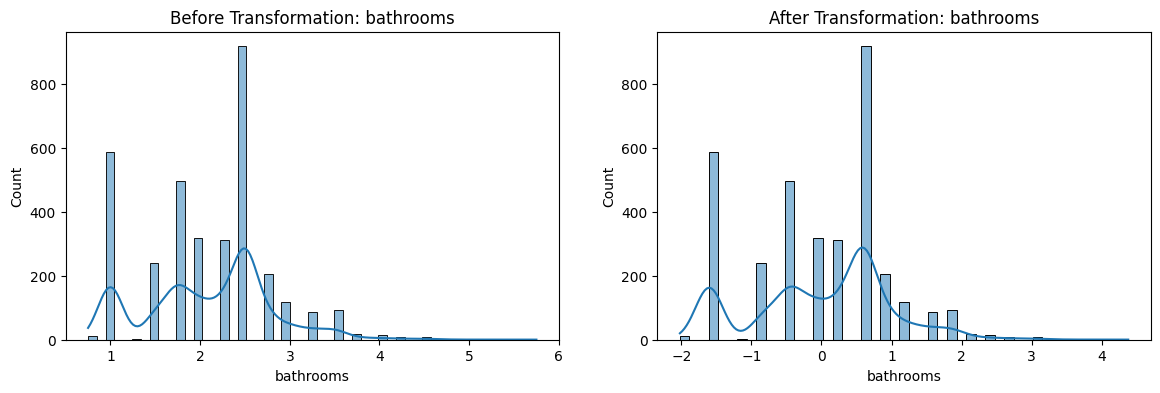

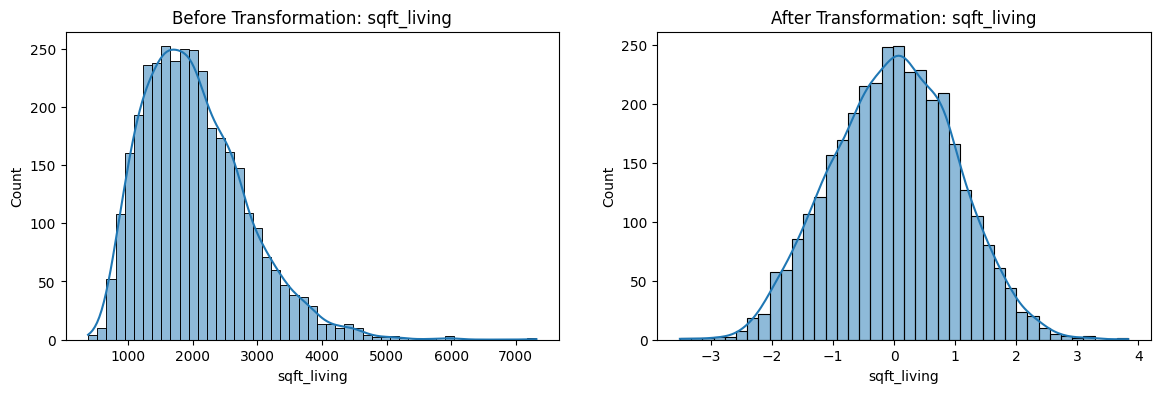

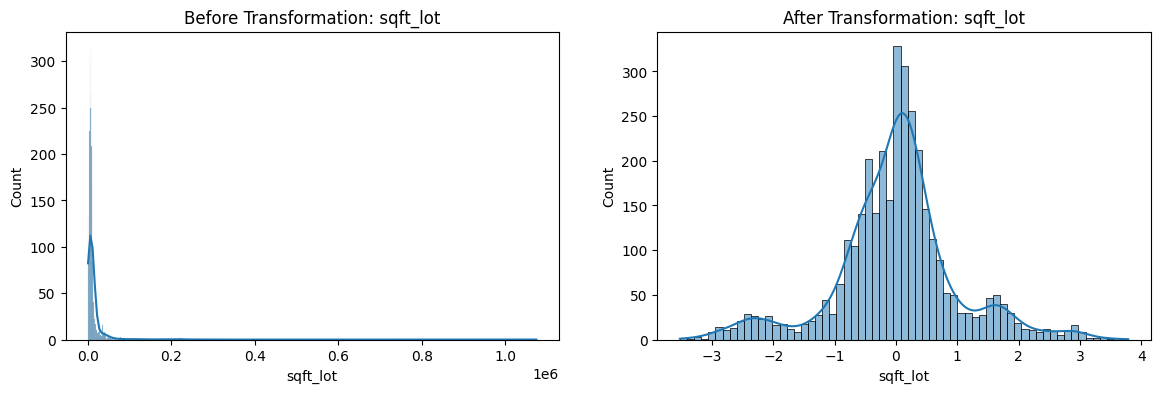

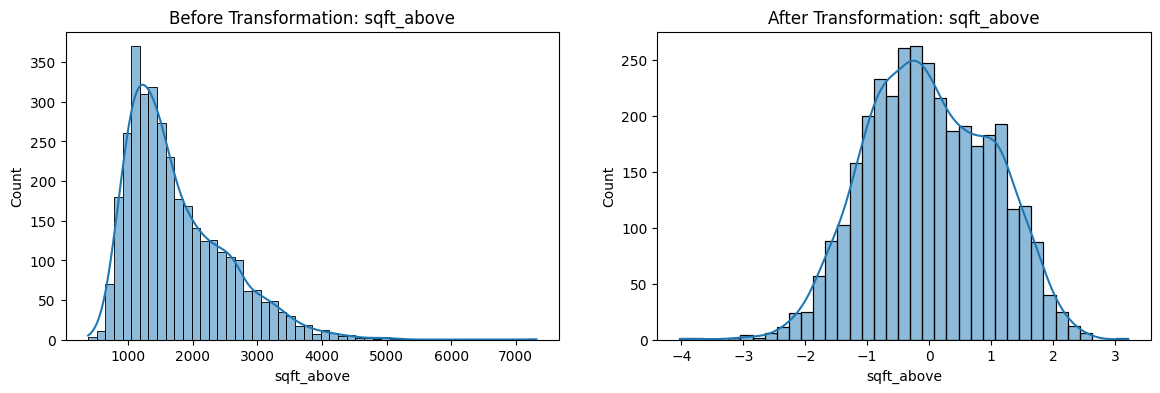

In [98]:
from sklearn.preprocessing import PowerTransformer

transform_cols = [
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'sqft_above'
]

pt = PowerTransformer(method='yeo-johnson')
X_train_transformed = pd.DataFrame(
    pt.fit_transform(X_train[transform_cols]),
    columns=transform_cols,
    index=X_train.index
)

for col in transform_cols:
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(X_train[col], kde=True)
    plt.title(f'Before Transformation: {col}')

    plt.subplot(1, 2, 2)
    sns.histplot(X_train_transformed[col], kde=True)
    plt.title(f'After Transformation: {col}')

    plt.show()

#### 4. Applying OneHotEncoding and Yeo-Johnson tranformation:

In [99]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder , PowerTransformer

transform_cols = [
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'sqft_above'
]

clt = ColumnTransformer(transformers=[
    ('yeo-johnson' , PowerTransformer(method= 'yeo-johnson' ) , transform_cols),
    ('ohe' , OneHotEncoder(handle_unknown='ignore') , ['city'])
] , remainder= 'passthrough')

#### 5. Applying Different Models::

In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [118]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
Gr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=3)

In [102]:
# for Random forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

#### 6. Creating Pipeline:

In [103]:
# for linear Regression
from sklearn.pipeline import Pipeline
Pipeline1 = Pipeline([
    ('preprocessor' , clt),
    ('lr' , lr)
    
])

In [ ]:
# for Gradient Boosting
Pipeline2 = Pipeline([
    ('preprocessor' , clt),
    ('Gr' , Gr)
    
])

In [105]:
# for Random forest
Pipeline3 = Pipeline([
    ('preprocessor' , clt),
    ('rf' , rf)
    
])

In [106]:
Pipeline1.fit(X_train , y_train)

,steps,"[('preprocessor', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('yeo-johnson', ...), ('ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [107]:
Pipeline2.fit(X_train , y_train)

,steps,"[('preprocessor', ...), ('Gr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('yeo-johnson', ...), ('ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [108]:
import joblib

joblib.dump(Pipeline2, "house_price_model.pkl")

['house_price_model.pkl']

In [109]:
Pipeline3.fit(X_train , y_train)

,steps,"[('preprocessor', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('yeo-johnson', ...), ('ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [110]:
y_pred1 = Pipeline1.predict(X_test)
y_pred1

array([ 383483.80287953,  477557.53736306,  619009.72512647,
        292455.29391457,  334392.72120461,  387216.89151985,
        593373.77545182,  360403.91637139,  808104.29544291,
        126994.40211489,  584534.16310716,  166814.54419239,
        310467.61146093,  595837.83676492,  583332.70033705,
        718371.10605244,  431966.46841774,  281743.28001782,
        649347.76567796,  504918.87504914,  529602.56030058,
        432771.1481609 ,  644616.57383088,  538707.94739915,
        664975.16453814,  667499.87106317,  585591.82198474,
        240370.63339242,  659982.03455899,  491514.19889042,
        521691.84657942,  426399.92089749,  438203.11091911,
        612138.43367113,  750296.07018154,  411556.80300171,
        325794.26851113,  786301.52596453,  478075.07887019,
        680575.24262383,  363254.18294975,  279430.74485293,
        643366.49881495,  753641.63288628,  498093.3094169 ,
        451511.22513933,  703689.47230042,  220406.26349634,
        292533.39837932,

In [111]:
y_pred2 = Pipeline2.predict(X_test)
y_pred2

array([ 436521.53149528,  523882.37496874,  610496.65080046,
        294524.36555934,  313228.8118604 ,  472157.03077448,
        440613.39060565,  323015.77784509,  834262.24563312,
        188558.36889599,  474209.92046543,  154710.98003336,
        322646.40159419,  602422.12263078,  572700.21439107,
        648476.39068432,  416799.56930226,  273201.14597656,
        624194.59065943,  521656.72100977,  485213.74664238,
        388116.28529485,  606445.45224946,  498940.41327412,
        628604.59804384,  669968.23374595,  529322.15974222,
        259940.25754028,  639389.81738284,  534849.00580641,
        504058.74631346,  407139.03443378,  438512.41469349,
        616024.81416807,  802504.89170545,  371172.10304458,
        323123.77971964,  736303.18761759,  428027.02064364,
        575683.81178324,  405998.59835752,  282917.55484389,
        692606.57574657,  703570.91662969,  490638.25688311,
        434080.43721911,  692019.45703664,  267584.41114067,
        255007.99701928,

In [112]:
y_pred3 = Pipeline3.predict(X_test)
y_pred3

array([515730.51851852, 525442.875     , 609724.92      , 270575.09589286,
       292616.41875   , 531027.76666667, 483730.06      , 293715.32999999,
       860213.        , 235240.00539682, 556913.25818184, 195146.484     ,
       285478.62092693, 639354.91      , 671259.87499999, 579058.80833331,
       449039.60666667, 276197.        , 700742.975     , 454305.15329671,
       534788.0515171 , 372807.6423077 , 664940.44347821, 566625.78333334,
       573767.70833332, 781893.        , 528190.0009091 , 279483.875     ,
       594187.88923077, 629212.14285713, 562921.3       , 443488.38      ,
       444528.05571429, 646533.945     , 763931.7435345 , 348366.66615384,
       348015.19714284, 719028.06857143, 488211.05454546, 635516.18      ,
       465031.03703704, 286016.33285714, 621527.        , 718385.81833333,
       424525.83333333, 447080.90476191, 697048.04463767, 242889.99571428,
       287345.83619049, 258987.33777777, 663307.89423077, 565099.76      ,
       535879.04166662, 3

#### 7. Checking MAE, MSE, R2 Score:

In [113]:
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error
print ('MSE of linear:',mean_squared_error(y_test , y_pred1))
print ('MAE of linear:',mean_absolute_error(y_test , y_pred1))
print ('R2_score of linear:',r2_score(y_test , y_pred1))

MSE of linear: 16621481470.187737
MAE of linear: 88932.25297640478
R2_score of linear: 0.6578513152522418


In [114]:
print ('MSE of Gradient :',mean_squared_error(y_test , y_pred2))
print ('MAE of Gradient:',mean_absolute_error(y_test , y_pred2))
print ('R2_score of Gradient:',r2_score(y_test , y_pred2))

MSE of Gradient : 14859209724.921402
MAE of Gradient: 82327.51067393398
R2_score of Gradient: 0.6941272008219174


In [115]:
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error
print ('MSE of Randomforest:',mean_squared_error(y_test , y_pred3))
print ('MAE of Randomforest:',mean_absolute_error(y_test , y_pred3))
print ('R2_score of Randomforest:',r2_score(y_test , y_pred3))

MSE of Randomforest: 15873609193.187086
MAE of Randomforest: 84992.88392846577
R2_score of Randomforest: 0.6732460630906962


In [116]:
sample= pd.DataFrame([{
    'bedrooms' : 6,
    'bathrooms': 2,
    'sqft_living': 1234,
    'sqft_lot': 2774,
    'view': 3,
    'condition': 2,
    'waterfront' : 1,
    'floors': 1,
    'sqft_above' :1267,
    'sqft_basement':2342,
    'house_Age':23,
    'is_renovated': 0,
    'city': 'Medina',
    'yr_since_renovated': 22,
}])

prediction = Pipeline2.predict(sample)[0]

print(f"Predicted House Price: ${prediction:,.2f}")


Predicted House Price: $304,194.92


"The dataset used in this project does not include construction-quality (grade) or precise geolocation (lat/long) features present in the original King County housing dataset. Since location and build quality are typically the strongest predictors of house price, their absence sets a practical ceiling on achievable R² (~65–70%) regardless of model choice or tuning. This was verified by testing target encoding, log-transformation, and hyperparameter tuning, none of which improved performance beyond this range."

Three regression models were trained and compared on the cleaned housing dataset to predict property prices: **Linear Regression**, **Gradient Boosting Regressor**, and **Random Forest Regressor**.

**Linear Regression** was applied first as a baseline. It achieved an R² score of 0.658, with a mean absolute error of approximately $88,932. This provided a reasonable starting benchmark and confirmed that the engineered features (Yeo-Johnson transformation on skewed columns, one-hot encoded city, and remaining passthrough features) carry meaningful linear signal for predicting price.

**Gradient Boosting Regressor** was applied next, with hyperparameters tuned via GridSearchCV (`n_estimators=300, learning_rate=0.1, max_depth=3`). This model outperformed Linear Regression, improving the R² score to 0.694 and reducing the mean absolute error to approximately $82,280. The improvement suggests that non-linear relationships and feature interactions in the data — which a linear model cannot capture — play a meaningful role in determining house price.

**Random Forest Regressor** was trained as a third comparison point. It produced an R² score of 0.673 and a mean absolute error of approximately $84,993 — better than Linear Regression, but slightly below the tuned Gradient Boosting model.

**Model comparison:**

| Model | R² Score | MAE |
|---|---|---|
| Linear Regression | 0.658 | $88,932 |
| Random Forest | 0.673 | $84,993 |
| **Gradient Boosting (tuned)** | **0.694** | **$82,280** |

**Final model:** Based on this comparison, the tuned **Gradient Boosting Regressor** was selected as the final model, as it achieved the highest R² score and lowest error across all three approaches. This result reflects the value of testing multiple model families rather than committing to a single algorithm upfront — the boosting model's ability to sequentially correct residual errors gave it an edge over both the linear baseline and the bagging-based Random Forest approach.
